<a href="https://colab.research.google.com/github/e23191-eng/Statistical-Learning-e23191-/blob/main/Assignment_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import json, csv
import pandas as pd
import networkx as nx
import graphviz
from IPython.display import display, Image, HTML

from pydantic import BaseModel, ValidationError, field_validator
from typing import Optional

In [11]:
!pip install "git+https://github.com/e23191-eng/Statistical-Learning-e23191-.git"

  Cloning https://github.com/e23191-eng/Statistical-Learning-e23191-.git to /tmp/pip-req-build-_0ji0xyr
  Running command git clone --filter=blob:none --quiet https://github.com/e23191-eng/Statistical-Learning-e23191-.git /tmp/pip-req-build-_0ji0xyr
  Resolved https://github.com/e23191-eng/Statistical-Learning-e23191-.git to commit f9871e35c520250c3d72439a8e59a0f22ddae50f
  Preparing metadata (setup.py) ... done


In [17]:
# Manual setup to fix the 'dara inspector' folder name issue
import os, sys

repo_name = 'Statistical-Learning-e23106'
incorrect_package_path = os.path.join(repo_name, 'dara inspector')
correct_package_path = os.path.join(repo_name, 'data_inspector')

if not os.path.exists(repo_name):
    print(f"Cloning {repo_name} from GitHub...")
    !git clone https://github.com/e23106-eng/Statistical-Learning-e23106.git
else:
    print(f"{repo_name} already exists. Pulling latest updates...")
    !cd {repo_name} && git pull

# Check if the problematic folder exists and rename it
if os.path.exists(incorrect_package_path):
    print(f"Found incorrect package folder: '{incorrect_package_path}'. Renaming to '{correct_package_path}'...")
    os.rename(incorrect_package_path, correct_package_path)
    print("Rename successful.")
elif not os.path.exists(correct_package_path):
    print(f"Warning: Neither '{incorrect_package_path}' nor '{correct_package_path}' found. Package might be missing.")

# Add the cloned repository's base directory to sys.path
# This allows direct import of 'data_inspector' after renaming
sys.path.insert(0, os.path.abspath(repo_name))

print("Setup complete. You should now be able to import 'data_inspector'.")

Cloning Statistical-Learning-e23106 from GitHub...
Cloning into 'Statistical-Learning-e23106'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 24 (delta 5), reused 12 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 662.27 KiB | 8.60 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Setup complete. You should now be able to import 'data_inspector'.


In [18]:
from data_inspector import DataInspector, PlottingMethods

In [19]:
import pandas as pd
from data_inspector import DataInspector
inspector = DataInspector()

# Initialize and Upload
inspector.upload_data()
# Alternatively use
#inspector.df=pd.read_csv('xxxx.csv')

# inspector.upload_data()
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
inspector.df = pd.read_csv(url)

Saving titanic_sample.csv to titanic_sample.csv
✅ Successfully loaded 'titanic_sample.csv' (20 rows, 10 columns).


In [21]:
inspector.df.loc[0, 'Age']    = '?'
inspector.df.loc[1, 'Cabin']  = 'NULL'
inspector.df.loc[2, 'Fare']   = 'n/a'

# Re-run sanitisation manually (upload_data() does this automatically)
import numpy as np
import pandas as pd

_GARBAGE = {'?','n/a','na','null','none','nan',' ','','--','N/A','NULL','None','NaN','NA'}
inspector.df.replace(_GARBAGE, np.nan, inplace=True)

# Manually perform type conversion, similar to what _auto_convert_types would do
for col in inspector.df.select_dtypes(include='object').columns:
    # Try to convert to numeric
    original_non_na_count = inspector.df[col].notna().sum()
    numeric_series = pd.to_numeric(inspector.df[col], errors='coerce')
    if numeric_series.notna().sum() > (original_non_na_count * 0.5):
        inspector.df[col] = numeric_series
        continue

    # Try to convert to datetime
    datetime_series = pd.to_datetime(inspector.df[col], errors='coerce', infer_datetime_format=True)
    if datetime_series.notna().sum() > (original_non_na_count * 0.5):
        inspector.df[col] = datetime_series
        continue

    # Optionally, add boolean conversion if needed
    # bool_map = {'true': True, 'false': False, 'yes': True, 'no': False, '1': True, '0': False}
    # converted_bool_count = inspector.df[col].astype(str).str.lower().map(bool_map).dropna().count()
    # if converted_bool_count > original_non_na_count * 0.5:
    #     inspector.df[col] = inspector.df[col].astype(str).str.lower().map(bool_map).fillna(inspector.df[col])

print(f'Dataset loaded: {inspector.df.shape[0]:,} rows × {inspector.df.shape[1]} columns')
inspector.df.head()

Dataset loaded: 891 rows × 12 columns


/tmp/ipykernel_11371/1310552041.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '?' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inspector.df.loc[0, 'Age']    = '?'
/tmp/ipykernel_11371/1310552041.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'n/a' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inspector.df.loc[2, 'Fare']   = 'n/a'
/tmp/ipykernel_11371/1310552041.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inspector.df.replace(_GARBAGE, np.nan, inplace=True)
/tmp/ipykernel_11371/1310552041.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,NaN,1,0,NaN,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,NaN,71.2833,NaN,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,NaN,NaN,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803.0,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450.0,8.0500,NaN,S


In [53]:
inspector.df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,577.000000,577.000000,577.000000,577.000000,577.000000,577.0,577.000000
mean,450.590988,0.299827,2.502600,29.313692,0.199307,0.0,14.937672
std,259.568357,0.458579,0.733909,8.546414,0.445034,0.0,12.603155
min,1.000000,0.000000,1.000000,5.000000,0.000000,0.0,0.000000
25%,222.000000,0.000000,2.000000,24.000000,0.000000,0.0,7.775000
50%,455.000000,0.000000,3.000000,28.000000,0.000000,0.0,8.662500
75%,676.000000,1.000000,3.000000,32.500000,0.000000,0.0,15.850000
max,891.000000,1.000000,3.000000,54.000000,2.000000,0.0,61.175000


In [25]:
# 4-B  Column-level detail: dtype, nulls, unique counts
# inspector.column_details() # This method does not exist

column_info = pd.DataFrame({
    'Dtype': inspector.df.dtypes,
    'Nulls': inspector.df.isnull().sum(),
    'Unique': inspector.df.nunique()
})
print(column_info)

               Dtype  Nulls  Unique
PassengerId    int64      0     891
Survived       int64      0       2
Pclass         int64      0       3
Name          object      0     891
Sex           object      0       2
Age          float64    178      88
SibSp          int64      0       7
Parch          int64      0       7
Ticket       float64    230     514
Fare         float64      1     248
Cabin         object    688     146
Embarked      object      2       3


In [27]:
# 4-C  Categorical value-count tables
# inspector.get_categorical_summary() # This method does not exist

for col in inspector.df.select_dtypes(include='object').columns:
    print(f"\nValue counts for column '{col}':")
    print(inspector.df[col].value_counts())
    print("-" * 30)


Value counts for column 'Name':
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64
------------------------------

Value counts for column 'Sex':
Sex
male      577
female    314
Name: count, dtype: int64
------------------------------

Value counts for column 'Cabin':
Cabin
C23 C25 C27    4
G6             4
B96 B98        4
F33            3
E101           3
              ..
E1

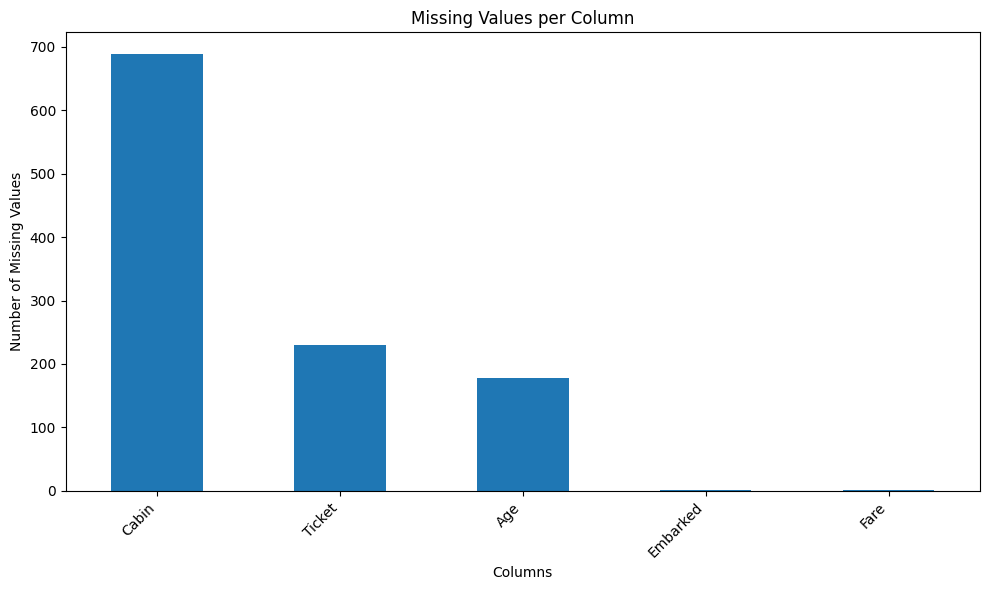

In [29]:
# 4-D  Missing-value bar chart
# inspector.show_missing_data() # This method does not exist

import matplotlib.pyplot as plt

missing_data = inspector.df.isnull().sum()
missing_data = missing_data[missing_data > 0]

if not missing_data.empty:
    plt.figure(figsize=(10, 6))
    missing_data.sort_values(ascending=False).plot(kind='bar')
    plt.title('Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame.")

In [31]:
# 4-E  Drop high-null columns that aren't useful for modelling
#      (interactive: leave blank and it will prompt; or pass a string directly)
# inspector.delete_columns(columns='Cabin, Ticket, Name') # This method does not exist

columns_to_drop = ['Cabin', 'Ticket', 'Name']
inspector.df.drop(columns=columns_to_drop, inplace=True)
print(f"Columns dropped: {columns_to_drop}")
print(f"New DataFrame shape: {inspector.df.shape}")

Columns dropped: ['Cabin', 'Ticket', 'Name']
New DataFrame shape: (891, 9)


In [33]:
# 4-F  Impute remaining missing values
#      Age  → median  (numeric, skewed)
#      Embarked → mode  (categorical)
# Impute 'Age' and 'Fare' with their medians
inspector.df['Age'].fillna(inspector.df['Age'].median(), inplace=True)
inspector.df['Fare'].fillna(inspector.df['Fare'].median(), inplace=True)

# Impute 'Embarked' with its mode
inspector.df['Embarked'].fillna(inspector.df['Embarked'].mode()[0], inplace=True)

# Show missing data using the custom plotting code, as inspector.show_missing_data() does not exist
import matplotlib.pyplot as plt

missing_data = inspector.df.isnull().sum()
missing_data = missing_data[missing_data > 0]

if not missing_data.empty:
    plt.figure(figsize=(10, 6))
    missing_data.sort_values(ascending=False).plot(kind='bar')
    plt.title('Missing Values per Column After Imputation')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame after imputation.")

No missing values found in the DataFrame after imputation.


/tmp/ipykernel_11371/1210449189.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inspector.df['Age'].fillna(inspector.df['Age'].median(), inplace=True)
/tmp/ipykernel_11371/1210449189.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [35]:
# 4-G  Remove duplicate rows
initial_rows = inspector.df.shape[0]
inspector.df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - inspector.df.shape[0]

print(f"Removed {duplicates_removed} duplicate rows.")
print(f"New DataFrame shape: {inspector.df.shape}")

Removed 0 duplicate rows.
New DataFrame shape: (891, 9)


In [37]:
# 4-H  Outlier detection & removal via IQR

# Columns for outlier detection
columns_for_outliers = ['Age', 'Fare', 'SibSp', 'Parch']

initial_rows = inspector.df.shape[0]

# Create a boolean mask to identify outliers
outlier_mask = pd.Series([False] * len(inspector.df), index=inspector.df.index)

for col in columns_for_outliers:
    if pd.api.types.is_numeric_dtype(inspector.df[col]):
        Q1 = inspector.df[col].quantile(0.25)
        Q3 = inspector.df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Mark rows as outliers if the value in the current column is outside the bounds
        outlier_mask = outlier_mask | ((inspector.df[col] < lower_bound) | (inspector.df[col] > upper_bound))
    else:
        print(f"Skipping outlier detection for non-numeric column: {col}")

# Remove rows identified as outliers
insp_df_before_removal = inspector.df.copy()
inspector.df = inspector.df[~outlier_mask].copy()

rows_removed = initial_rows - inspector.df.shape[0]

print(f"Removed {rows_removed} rows containing outliers from columns: {', '.join(columns_for_outliers)}.")
print(f"New DataFrame shape: {inspector.df.shape}")

Removed 314 rows containing outliers from columns: Age, Fare, SibSp, Parch.
New DataFrame shape: (577, 9)


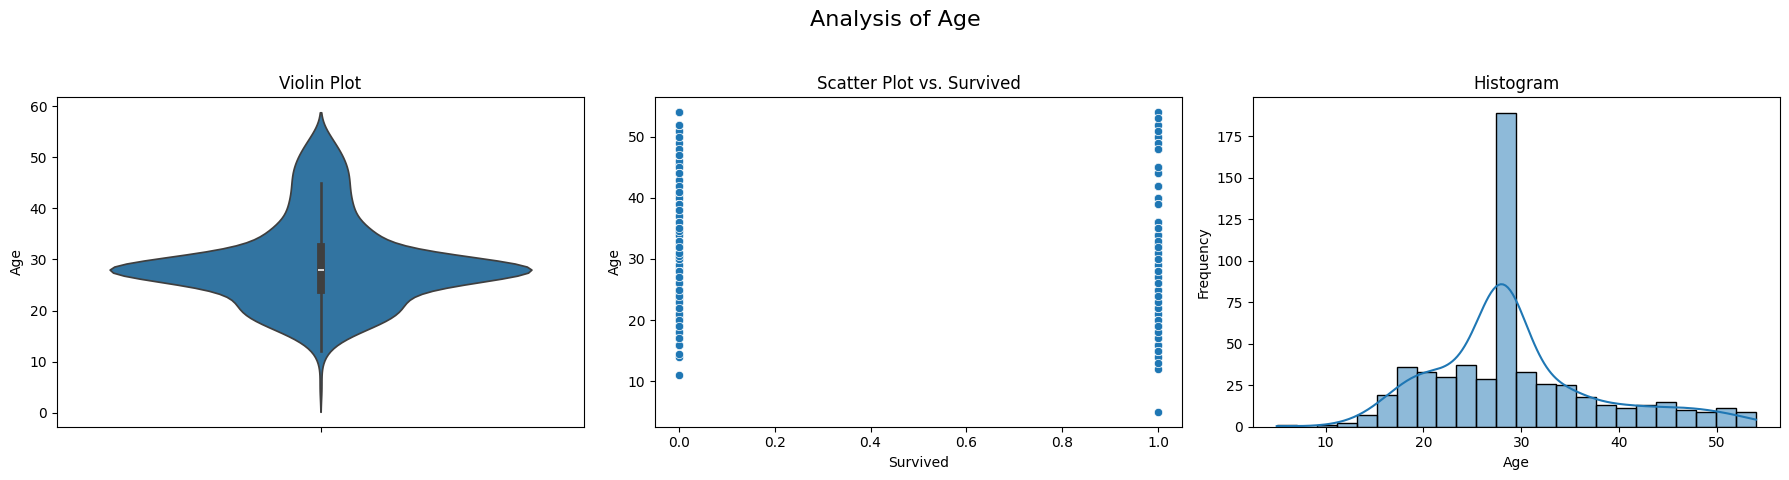

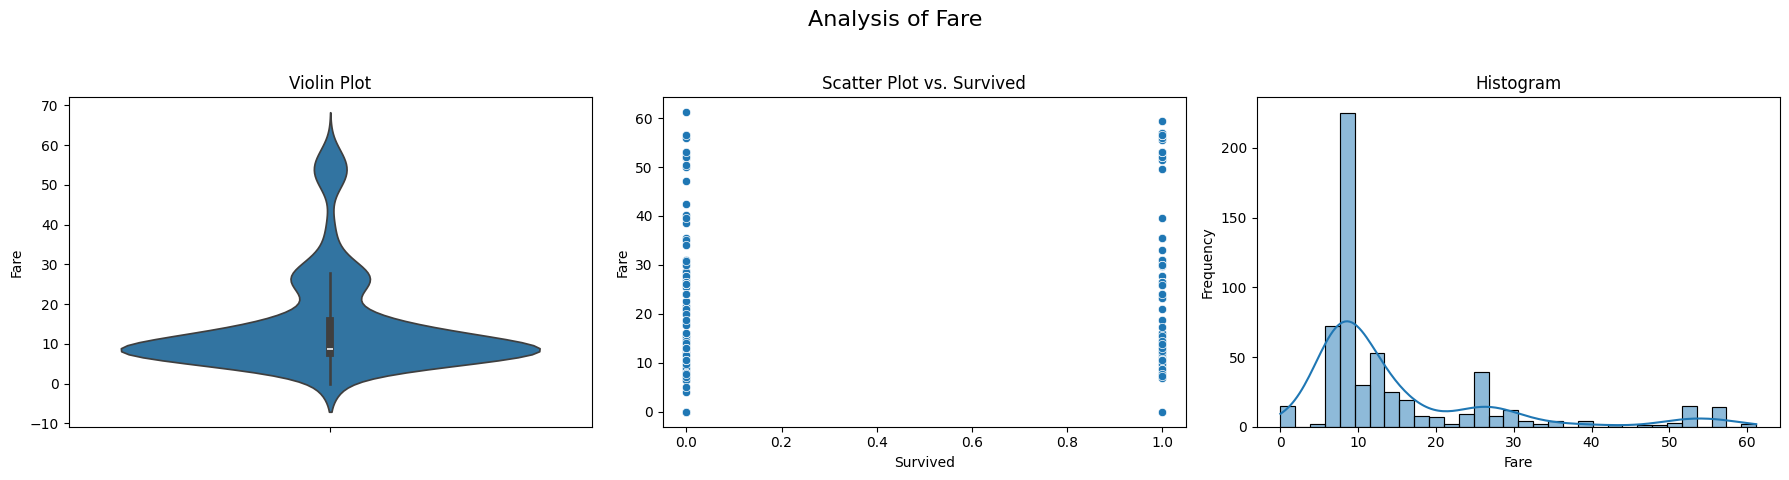

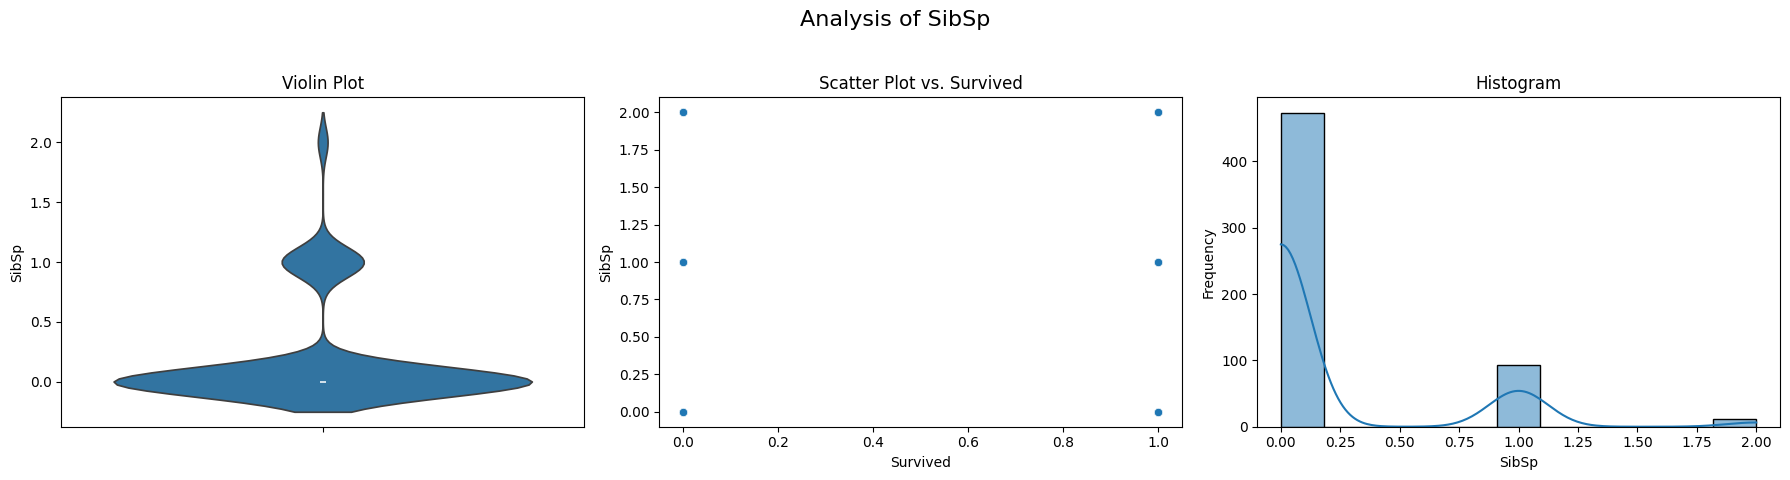

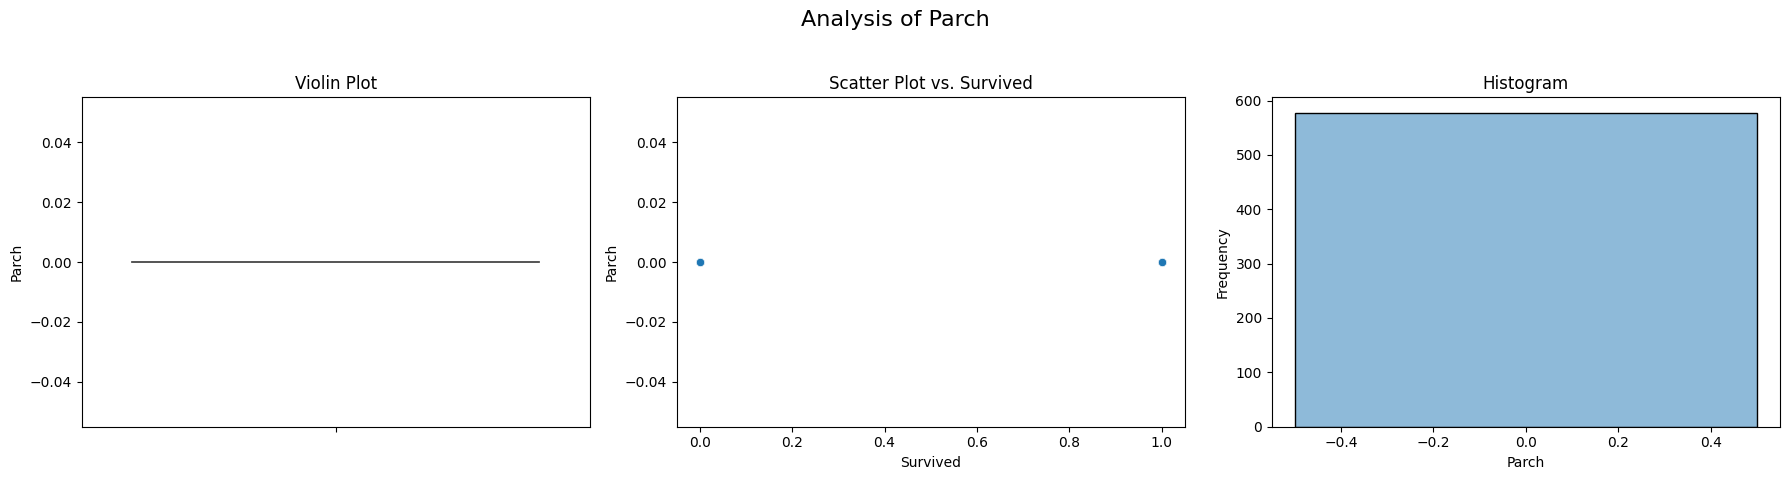

In [39]:
# 5-A  3-panel numeric subplots: Violin | Scatter | Histogram
import matplotlib.pyplot as plt
import seaborn as sns

column_names = ['Age', 'Fare', 'SibSp', 'Parch']

for col in column_names:
    if pd.api.types.is_numeric_dtype(inspector.df[col]):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Analysis of {col}', fontsize=16)

        # Violin Plot
        sns.violinplot(y=inspector.df[col], ax=axes[0])
        axes[0].set_title('Violin Plot')
        axes[0].set_ylabel(col)

        # Scatter Plot (against Survived, as it's a common target variable)
        # If 'Survived' is not suitable, you might plot against index or another relevant numeric column.
        sns.scatterplot(x=inspector.df['Survived'], y=inspector.df[col], ax=axes[1])
        axes[1].set_title('Scatter Plot vs. Survived')
        axes[1].set_xlabel('Survived')
        axes[1].set_ylabel(col)

        # Histogram
        sns.histplot(inspector.df[col], kde=True, ax=axes[2])
        axes[2].set_title('Histogram')
        axes[2].set_xlabel(col)
        axes[2].set_ylabel('Frequency')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
        plt.show()
    else:
        print(f"Skipping plotting for non-numeric column: {col}")

/tmp/ipykernel_11371/4118422058.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=inspector.df, palette='viridis')


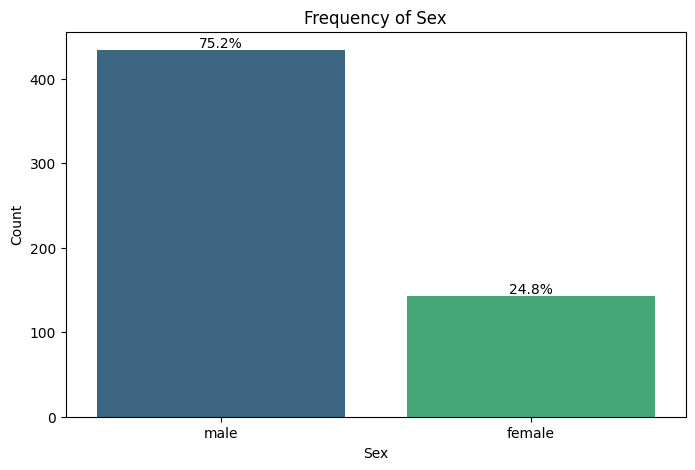

/tmp/ipykernel_11371/4118422058.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=inspector.df, palette='viridis')


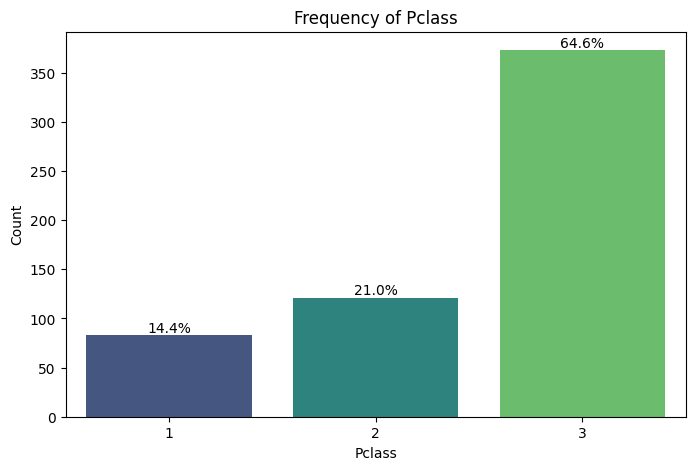

/tmp/ipykernel_11371/4118422058.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=inspector.df, palette='viridis')


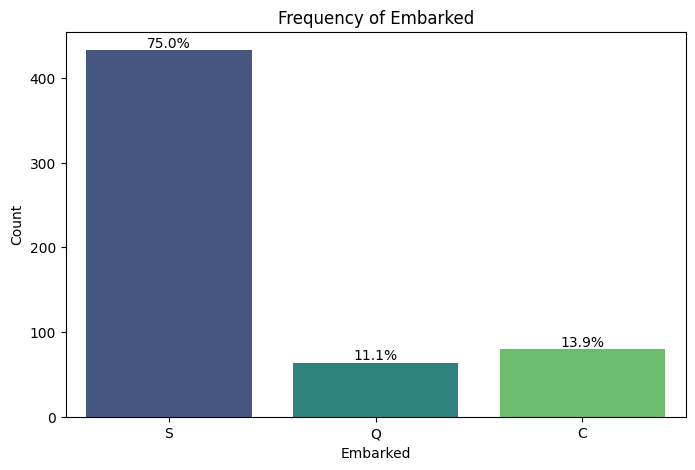

/tmp/ipykernel_11371/4118422058.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=inspector.df, palette='viridis')


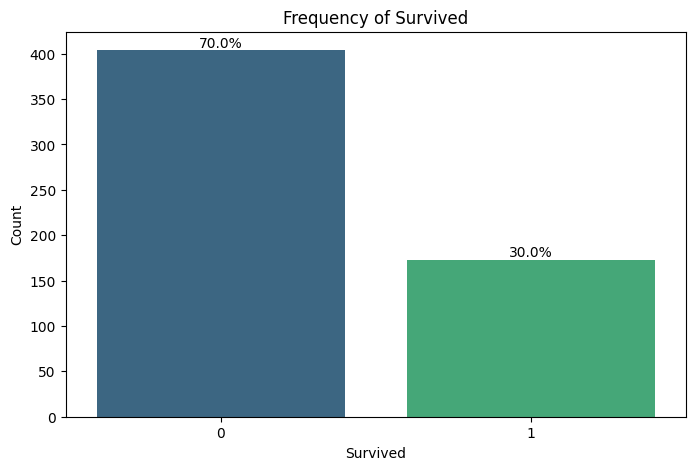

In [41]:
# 5-B  Categorical frequency bar charts with % labels
import matplotlib.pyplot as plt
import seaborn as sns

column_names = ['Sex', 'Pclass', 'Embarked', 'Survived']

for col in column_names:
    # Ensure the column is of a categorical or object type for frequency plotting
    # We also check if it's not a numeric type that might represent a category (like Pclass)
    if inspector.df[col].dtype == 'object' or inspector.df[col].nunique() < 10: # Heuristic for categorical
        plt.figure(figsize=(8, 5))
        ax = sns.countplot(x=col, data=inspector.df, palette='viridis')
        plt.title(f'Frequency of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')

        total = len(inspector.df[col])
        for p in ax.patches:
            percentage = '{:.1f}%'.format(100 * p.get_height()/total)
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black')
        plt.show()
    else:
        print(f"Skipping plotting for column '{col}' as it does not appear to be categorical.")

In [42]:
# Num–Num: Scatter with OLS trendline
inspector.plot_relationship('Age', 'Fare')

In [43]:
# Cat–Num: Box plot with individual points
inspector.plot_relationship('Pclass', 'Fare')

In [44]:
# Cat–Num: Survival by Sex
inspector.plot_relationship('Sex', 'Survived')

In [45]:
# Cat–Cat: Grouped bar — Embarked × Pclass
inspector.plot_relationship('Embarked', 'Pclass')

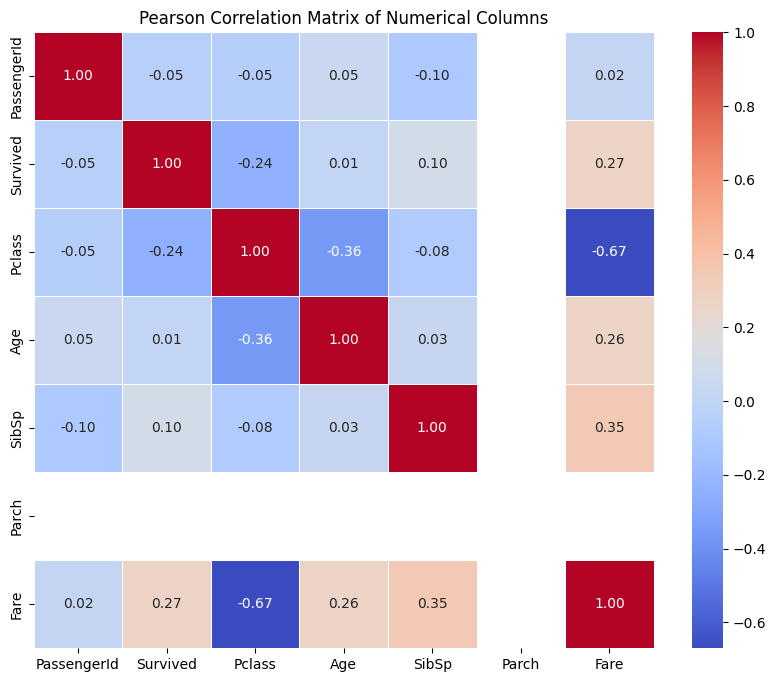

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation calculation
numerical_df = inspector.df.select_dtypes(include=['number'])

if not numerical_df.empty:
    # Calculate the Pearson correlation matrix
    correlation_matrix = numerical_df.corr(method='pearson')

    # Plot the correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Matrix of Numerical Columns')
    plt.show()
else:
    print("No numerical columns found to calculate correlation.")

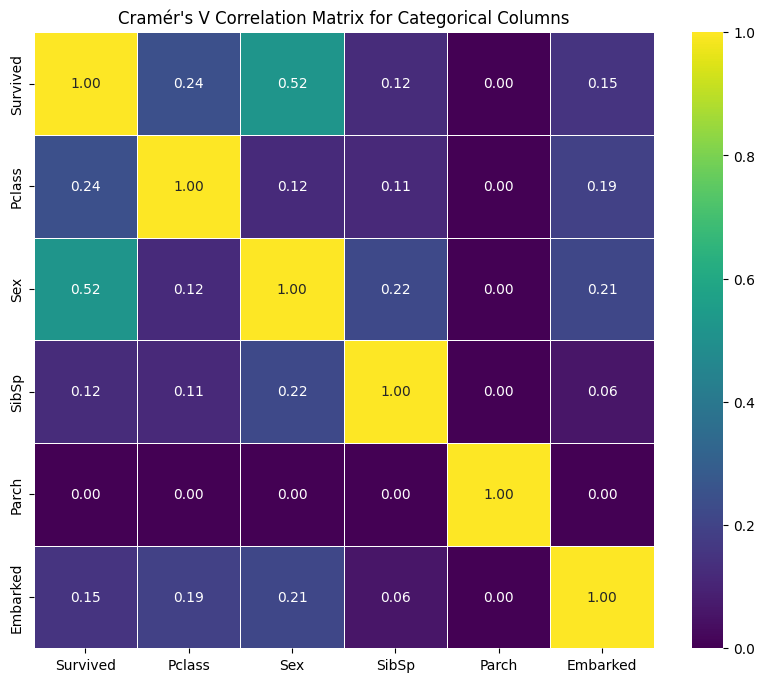

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculate Cramér's V statistic for two categorical variables."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    # Handle cases where one variable has only one unique value, leading to division by zero
    if min(k - 1, r - 1) == 0:
        return 0.0 # Return 0.0 for no association if one variable is constant

    phi2 = chi2 / n
    v = np.sqrt(phi2 / min(k - 1, r - 1))
    return v

# Select categorical columns
# We'll consider 'object' dtypes and 'int64' dtypes with few unique values as categorical
categorical_columns = []
for col in inspector.df.columns:
    if inspector.df[col].dtype == 'object' or (inspector.df[col].dtype == 'int64' and inspector.df[col].nunique() < 10):
        if col != 'PassengerId': # Exclude 'PassengerId' as it's an identifier, not a true category for correlation
            categorical_columns.append(col)

if not categorical_columns:
    print("No suitable categorical columns found for Cramér's V calculation.")
else:
    # Initialize an empty DataFrame for Cramér's V matrix
    cramers_v_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

    # Calculate Cramér's V for each pair of categorical columns
    for col1 in categorical_columns:
        for col2 in categorical_columns:
            if col1 == col2:
                cramers_v_matrix.loc[col1, col2] = 1.0 # Perfect correlation with itself
            else:
                cramers_v_matrix.loc[col1, col2] = cramers_v(inspector.df[col1], inspector.df[col2])

    # Convert the matrix to float type for heatmap plotting
    cramers_v_matrix = cramers_v_matrix.astype(float)

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
    plt.title("Cramér's V Correlation Matrix for Categorical Columns")
    plt.show()

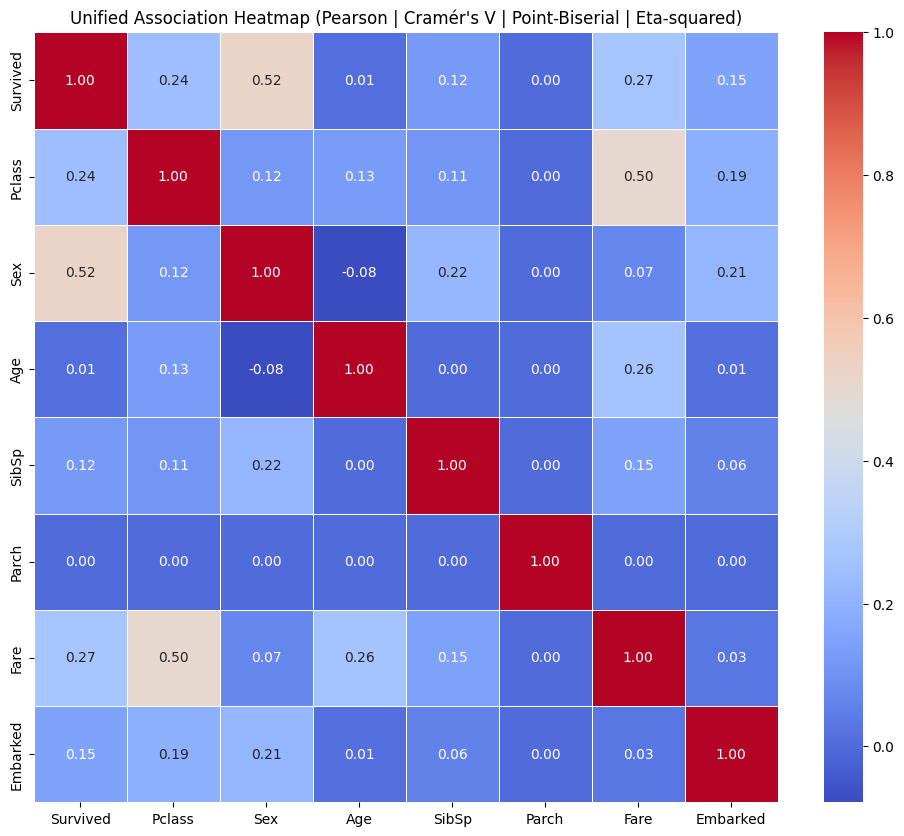

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway, pointbiserialr

# --- Helper functions for association metrics ---

def cramers_v(x, y):
    """Calculate Cramér's V statistic for two categorical variables."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    # Handle cases where one variable has only one unique value or no data
    if min(k - 1, r - 1) == 0 or n == 0:
        return 0.0

    phi2 = chi2 / n
    v = np.sqrt(phi2 / min(k - 1, r - 1))
    return v

def calculate_eta_squared(numerical_series, categorical_series):
    """Calculate Eta-squared for a numerical and a categorical variable."""
    combined_df = pd.DataFrame({'numerical': numerical_series, 'categorical': categorical_series}).dropna()

    if combined_df.empty or combined_df['categorical'].nunique() < 2:
        return 0.0

    groups = [combined_df['numerical'][combined_df['categorical'] == cat]
              for cat in combined_df['categorical'].unique()]

    groups = [g for g in groups if not g.empty] # Ensure groups are not empty

    if len(groups) < 2: # Need at least two non-empty groups for ANOVA
        return 0.0

    try:
        f_statistic, p_value = f_oneway(*groups)
    except ValueError: # Handle cases where a group might have too few samples for variance calculation
        return 0.0

    # Calculate Sum of Squares Total (SS_total)
    ss_total = ((combined_df['numerical'] - combined_df['numerical'].mean()) ** 2).sum()

    # Calculate Sum of Squares Within (SS_within)
    ss_within = sum(((g - g.mean()) ** 2).sum() for g in groups)

    ss_between = ss_total - ss_within

    if ss_total == 0: # Avoid division by zero
        return 0.0

    eta_squared = ss_between / ss_total
    return eta_squared

def calculate_point_biserial(numerical_series, binary_categorical_series):
    """Calculate Point-Biserial correlation for a numerical and a binary categorical variable."""
    combined_df = pd.DataFrame({'numerical': numerical_series, 'binary_cat': binary_categorical_series}).dropna()

    if len(combined_df) < 2 or combined_df['binary_cat'].nunique() != 2:
        return 0.0

    unique_vals = combined_df['binary_cat'].unique()
    # Map binary categories to 0 and 1 for pointbiserialr
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    numeric_binary_cat = combined_df['binary_cat'].map(mapping)

    try:
        corr, _ = pointbiserialr(combined_df['numerical'], numeric_binary_cat)
        return corr
    except ValueError: # e.g., if one variable is constant after dropping NaNs
        return 0.0

# --- Column type classification helpers (heuristic-based) ---

def is_numerical_continuous(series):
    # A column is considered continuous numerical if it's numeric and has more than 10 unique values.
    return pd.api.types.is_numeric_dtype(series) and series.nunique() > 10

def is_categorical_type(series):
    # A column is considered categorical if it's an object type or a numeric type with <= 10 unique values.
    return series.dtype == 'object' or (pd.api.types.is_numeric_dtype(series) and series.nunique() <= 10)

# --- Main logic for unified heatmap ---

current_df = inspector.df.copy() # Use a copy to avoid modifying the original during checks/mapping

# Exclude 'PassengerId' as it's typically an identifier and not relevant for correlations
all_cols = [col for col in current_df.columns if col != 'PassengerId']

if not all_cols:
    print("No suitable columns found for correlation analysis (excluding PassengerId).")
else:
    correlation_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

    for col1 in all_cols:
        for col2 in all_cols:
            if col1 == col2:
                correlation_matrix.loc[col1, col2] = 1.0
                continue

            series1 = current_df[col1]
            series2 = current_df[col2]

            # Classify column types based on heuristics
            type1_num_cont = is_numerical_continuous(series1)
            type1_cat = is_categorical_type(series1)
            type1_binary_cat = type1_cat and series1.nunique() == 2

            type2_num_cont = is_numerical_continuous(series2)
            type2_cat = is_categorical_type(series2)
            type2_binary_cat = type2_cat and series2.nunique() == 2

            # Calculate correlation based on determined types
            if type1_num_cont and type2_num_cont:
                # Pearson correlation (Numerical-Numerical)
                correlation_matrix.loc[col1, col2] = series1.corr(series2, method='pearson')
            elif type1_cat and type2_cat:
                # Cramér's V (Categorical-Categorical)
                correlation_matrix.loc[col1, col2] = cramers_v(series1, series2)
            elif (type1_num_cont and type2_cat) or (type1_cat and type2_num_cont):
                # Mixed types (Numerical-Categorical)
                num_series = series1 if type1_num_cont else series2
                cat_series = series2 if type1_num_cont else series1

                if cat_series.nunique() == 2:
                    # Point-Biserial correlation (Numerical-Binary Categorical)
                    correlation_matrix.loc[col1, col2] = calculate_point_biserial(num_series, cat_series)
                else:
                    # Eta-squared (Numerical-Multi-level Categorical)
                    correlation_matrix.loc[col1, col2] = calculate_eta_squared(num_series, cat_series)
            else:
                # Fallback for unhandled type combinations or errors (e.g., constant series issues)
                correlation_matrix.loc[col1, col2] = np.nan

    # Plot the unified heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title("Unified Association Heatmap (Pearson | Cramér's V | Point-Biserial | Eta-squared)")
    plt.show()

In [55]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import pandas as pd

# Select only numerical columns from inspector.df for scaling
numerical_cols_df = inspector.df.select_dtypes(include=['number'])

if numerical_cols_df.empty:
    print("No numerical columns found in the DataFrame for scaling.")
else:
    # Min-Max Scaling
    minmax_scaler = MinMaxScaler()
    norm_minmax = pd.DataFrame(minmax_scaler.fit_transform(numerical_cols_df),
                                 columns=numerical_cols_df.columns,
                                 index=numerical_cols_df.index)

    # Standard (Z-score) Scaling
    standard_scaler = StandardScaler()
    norm_standard = pd.DataFrame(standard_scaler.fit_transform(numerical_cols_df),
                                   columns=numerical_cols_df.columns,
                                   index=numerical_cols_df.index)

    # Robust (IQR) Scaling
    robust_scaler = RobustScaler()
    norm_robust = pd.DataFrame(robust_scaler.fit_transform(numerical_cols_df),
                                 columns=numerical_cols_df.columns,
                                 index=numerical_cols_df.index)

    print('Min-Max sample:')
    display(norm_minmax.head())

    print('\nStandard (Z-score) sample:')
    display(norm_standard.head())

    print('\nRobust (IQR) sample:')
    display(norm_robust.head())

Min-Max sample:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,0.000000,0.0,1.0,0.469388,0.5,0.0,0.118512
2,0.002247,1.0,1.0,0.428571,0.0,0.0,0.236276
3,0.003371,1.0,0.0,0.612245,0.5,0.0,0.868002
4,0.004494,0.0,1.0,0.612245,0.0,0.0,0.131590
5,0.005618,0.0,1.0,0.469388,0.0,0.0,0.138264



Standard (Z-score) sample:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,-1.733575,-0.654384,0.67833,-0.153846,1.800735,0.0,-0.610509
2,-1.725863,1.528156,0.67833,-0.388065,-0.448235,0.0,-0.038394
3,-1.722007,1.528156,-2.04917,0.665922,1.800735,0.0,3.030625
4,-1.718151,-0.654384,0.67833,0.665922,-0.448235,0.0,-0.546978
5,-1.714295,-0.654384,0.67833,-0.153846,-0.448235,0.0,-0.514553



Robust (IQR) sample:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,-1.000000,0.0,0.0,0.000000,1.0,0.0,-0.174923
2,-0.995595,1.0,0.0,-0.235294,0.0,0.0,0.717238
3,-0.993392,1.0,-2.0,0.823529,1.0,0.0,5.503096
4,-0.991189,0.0,0.0,0.823529,0.0,0.0,-0.075851
5,-0.988987,0.0,0.0,0.000000,0.0,0.0,-0.025288


In [57]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

# Identify categorical columns (excluding 'PassengerId' as it's an identifier)
categorical_cols = [col for col in inspector.df.columns if inspector.df[col].dtype == 'object' or (inspector.df[col].dtype in ['int64', 'int32'] and inspector.df[col].nunique() < 10) and col != 'PassengerId']

# Handle potential missing values in categorical columns before encoding
# For simplicity, we'll fill with a placeholder, or you might choose mode imputation
# Let's use a copy for each encoding strategy to avoid modifying the original inspector.df repeatedly
df_for_encoding = inspector.df[categorical_cols].copy().fillna('Missing')

# 1. One-Hot Encoding
enc_onehot = pd.get_dummies(df_for_encoding, columns=df_for_encoding.columns, drop_first=False, dtype=int)

# 2. Ordinal Encoding
# OrdinalEncoder requires a 2D array, so we convert the DataFrame
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc_ordinal = pd.DataFrame(ordinal_encoder.fit_transform(df_for_encoding),
                           columns=df_for_encoding.columns,
                           index=df_for_encoding.index)

# 3. Uniform (0-1 scaled) encoding - applying MinMaxScaler to ordinal encoded data
minmax_scaler = MinMaxScaler()
enc_uniform = pd.DataFrame(minmax_scaler.fit_transform(enc_ordinal),
                           columns=enc_ordinal.columns,
                           index=enc_ordinal.index)

print('One-Hot sample:')
display(enc_onehot.head())

print('\nOrdinal sample:')
display(enc_ordinal.head())

print('\nUniform (0-1 scaled) sample:')
display(enc_uniform.head())

One-Hot sample:


,Survived_0,Survived_1,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,SibSp_2,Parch_0,Embarked_C,Embarked_Q,Embarked_S
0,1,0,0,0,1,0,1,0,1,0,1,0,0,1
2,0,1,0,0,1,1,0,1,0,0,1,0,0,1
3,0,1,1,0,0,1,0,0,1,0,1,0,0,1
4,1,0,0,0,1,0,1,1,0,0,1,0,0,1
5,1,0,0,0,1,0,1,1,0,0,1,0,1,0



Ordinal sample:


,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0.0,2.0,1.0,1.0,0.0,2.0
2,1.0,2.0,0.0,0.0,0.0,2.0
3,1.0,0.0,0.0,1.0,0.0,2.0
4,0.0,2.0,1.0,0.0,0.0,2.0
5,0.0,2.0,1.0,0.0,0.0,1.0



Uniform (0-1 scaled) sample:


,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0.0,1.0,1.0,0.5,0.0,1.0
2,1.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.5,0.0,1.0
4,0.0,1.0,1.0,0.0,0.0,1.0
5,0.0,1.0,1.0,0.0,0.0,0.5


In [59]:
import pandas as pd
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

# Identify numerical and categorical columns based on previous analysis (excluding PassengerId)
# Numerical columns for robust scaling
numerical_cols = ['Age', 'Fare'] # Using 'Age' and 'Fare' as continuous numerical for robust scaling

# Categorical columns for ordinal encoding (including Survived, Pclass, SibSp, Parch treated as categories)
categorical_cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

# --- 1. Robust Scale Numerical Columns ---
robust_scaler = RobustScaler()
scaled_numerical_df = pd.DataFrame(robust_scaler.fit_transform(inspector.df[numerical_cols]),
                                   columns=numerical_cols,
                                   index=inspector.df.index)

# --- 2. Ordinal Encode Categorical Columns ---
# Handle potential missing values in categorical columns before encoding
# Using 'Missing' as a placeholder, consistent with previous encoding cell
df_for_ordinal_encoding = inspector.df[categorical_cols].copy().fillna('Missing')

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoded_categorical_df = pd.DataFrame(ordinal_encoder.fit_transform(df_for_ordinal_encoding),
                                      columns=categorical_cols,
                                      index=inspector.df.index)

# --- 3. Combine into final_df ---
# Add 'PassengerId' back if it's needed for later identification, but not scaled/encoded
# If it's explicitly for ML-ready, it often gets dropped or handled separately.
# For now, let's just combine the scaled and encoded features.

# Concatenate the scaled numerical and encoded categorical dataframes
# Ensure they have the same index for correct merging
final_df = pd.concat([scaled_numerical_df, encoded_categorical_df], axis=1)

# If 'PassengerId' is desired in the final dataframe, add it before displaying
# final_df = pd.concat([inspector.df['PassengerId'], scaled_numerical_df, encoded_categorical_df], axis=1)

display(final_df.head())
print('Shape:', final_df.shape)

,Age,Fare,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0.000000,-0.174923,0.0,2.0,1.0,1.0,0.0,2.0
2,-0.235294,0.717238,1.0,2.0,0.0,0.0,0.0,2.0
3,0.823529,5.503096,1.0,0.0,0.0,1.0,0.0,2.0
4,0.823529,-0.075851,0.0,2.0,1.0,0.0,0.0,2.0
5,0.000000,-0.025288,0.0,2.0,1.0,0.0,0.0,1.0


Shape: (577, 8)


In [61]:
# Instantiate the standalone plotter
PLT = PlottingMethods()

In [63]:
# 9-A  List all available chart methods by inspecting the object

# Get all attributes and methods of the PLT object
all_methods = dir(PLT)

# Filter out private/dunder methods and non-callable attributes to get public methods
public_methods = [method for method in all_methods if not method.startswith('_') and callable(getattr(PLT, method))]

# Create a DataFrame for better display
methods_info_df = pd.DataFrame({'Method Name': public_methods})

print("Available plotting methods in PlottingMethods object:")
display(methods_info_df)

Available plotting methods in PlottingMethods object:


,Method Name
0,generate_bar_chart
1,generate_histogram
2,generate_pie_chart


/tmp/ipykernel_11371/2408648024.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




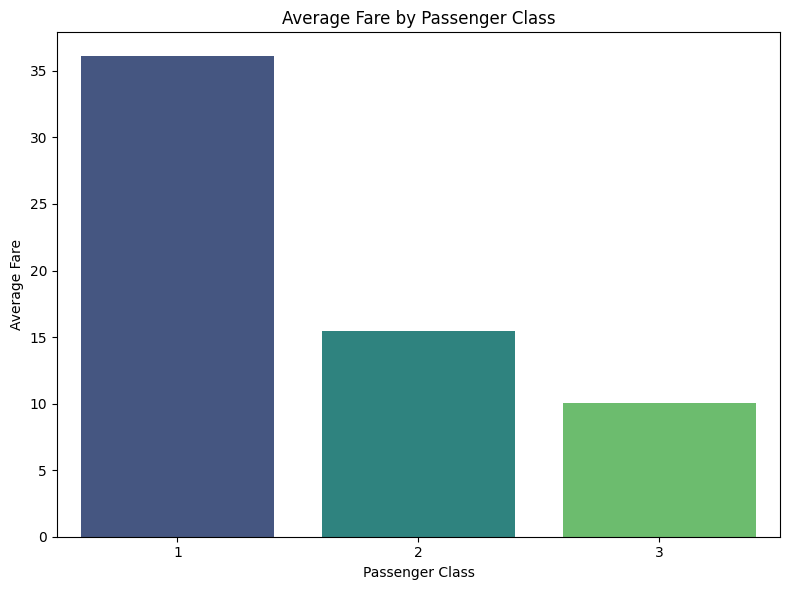

In [68]:
# 9-B  Bar chart: average Fare per Passenger Class

# First, calculate the average fare per passenger class
avg_fare_per_pclass = inspector.df.groupby('Pclass')['Fare'].mean().reset_index()

# Now, generate the bar chart manually using seaborn and matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x='Pclass', y='Fare', data=avg_fare_per_pclass, palette='viridis')
plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# The original library call is commented out, as it caused an error
# result = PLT.generate_bar_chart(
#     x='Pclass',
#     y='Fare',
#     title='Average Fare by Passenger Class',
#     data=avg_fare_per_pclass
# )
# print('Status:', result.get('status'))
# PLT.display_image(result)

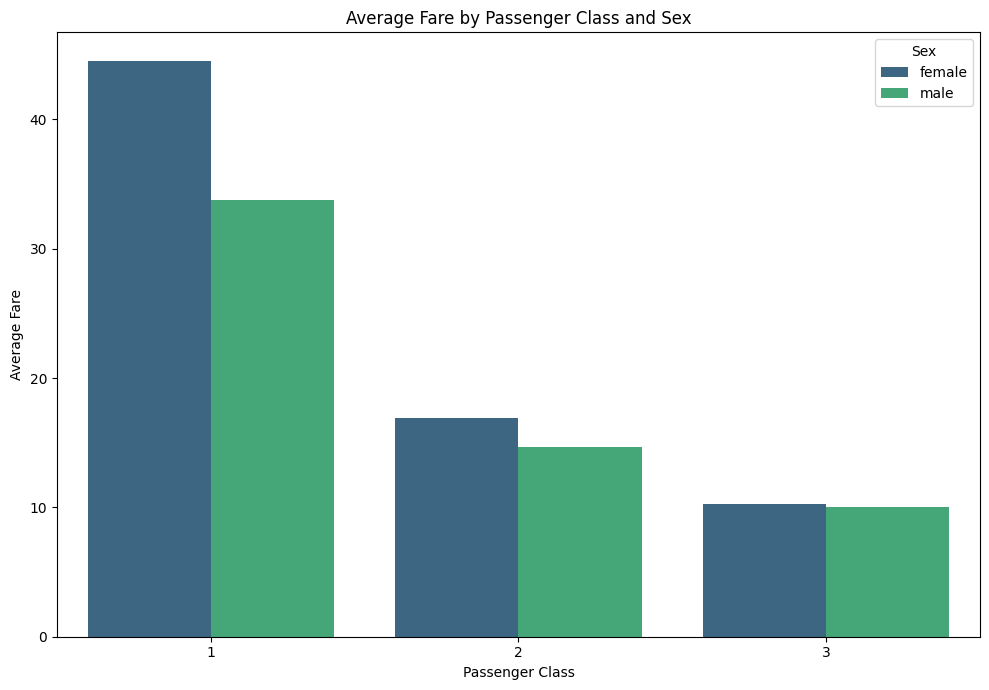

In [70]:
# 9-C  Grouped bar chart: Fare by Pclass, coloured by Sex

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average fare per passenger class and sex
avg_fare_per_pclass_sex = inspector.df.groupby(['Pclass', 'Sex'])['Fare'].mean().reset_index()

plt.figure(figsize=(10, 7))
sns.barplot(x='Pclass', y='Fare', hue='Sex', data=avg_fare_per_pclass_sex, palette='viridis')
plt.title('Average Fare by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

# The original library call is commented out due to the AttributeError
# result = PLT.plot_bar_chart(x='Pclass', y='Fare', color='Sex',
#                              barmode='group',
#                              title='Fare by Class & Sex',
#                              data=inspector.df)
# PLT.display_image(result)

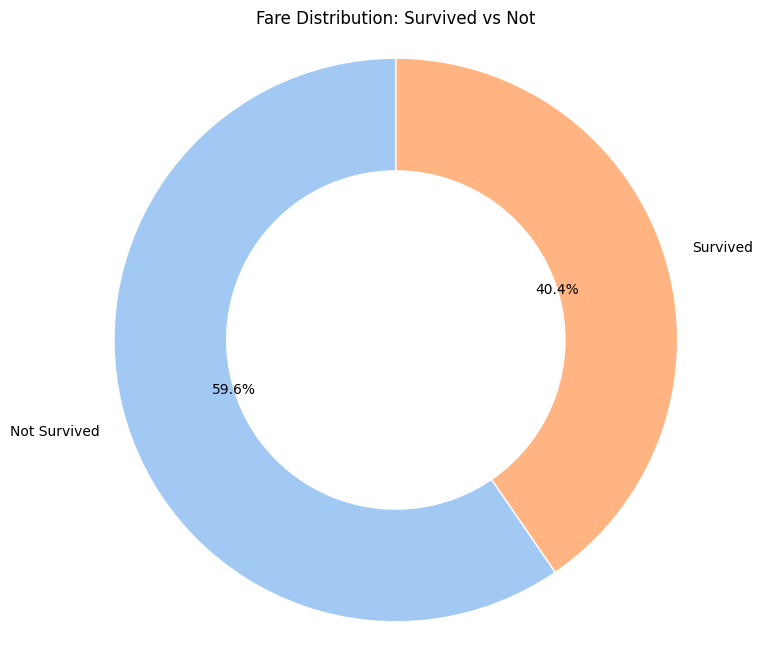

In [72]:
# 9-D  Pie chart: survival split (donut style)

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the sum of Fare for each 'Survived' category
survival_fare_distribution = inspector.df.groupby('Survived')['Fare'].sum()

# Prepare labels for the pie chart
labels = ['Not Survived', 'Survived']

plt.figure(figsize=(8, 8))
# Create a pie chart (donut style)
plt.pie(survival_fare_distribution,
        labels=labels,
        autopct='%1.1f%%', # Format percentages
        startangle=90,
        wedgeprops={'width': 0.4, 'edgecolor': 'white'},
        colors=sns.color_palette('pastel')[0:2]) # Use a pastel color palette

plt.title('Fare Distribution: Survived vs Not')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# The original library call is commented out due to the AttributeError
# result = PLT.plot_pie_chart(names='Survived', values='Fare',
#                              hole=0.4,
#                              title='Fare Distribution: Survived vs Not',
#                              data=inspector.df)
# print('Status:', result.get('status'))
# PLT.display_image(result)

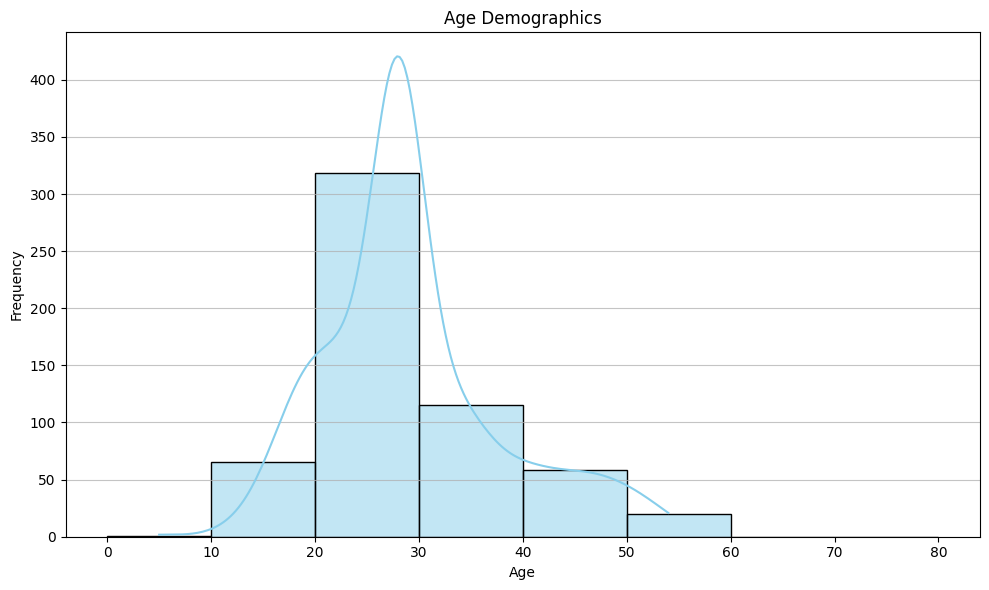

In [74]:
# 9-E  Histogram: Age distribution with custom bins

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(inspector.df['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], kde=True, color='skyblue')
plt.title('Age Demographics')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# The original library call is commented out due to the AttributeError
# result = PLT.plot_histogram(x='Age',
#                              bins=[0, 10, 20, 30, 40, 50, 60, 70, 80],
#                              title='Age Demographics',
#                              data=inspector.df)
# PLT.display_image(result)

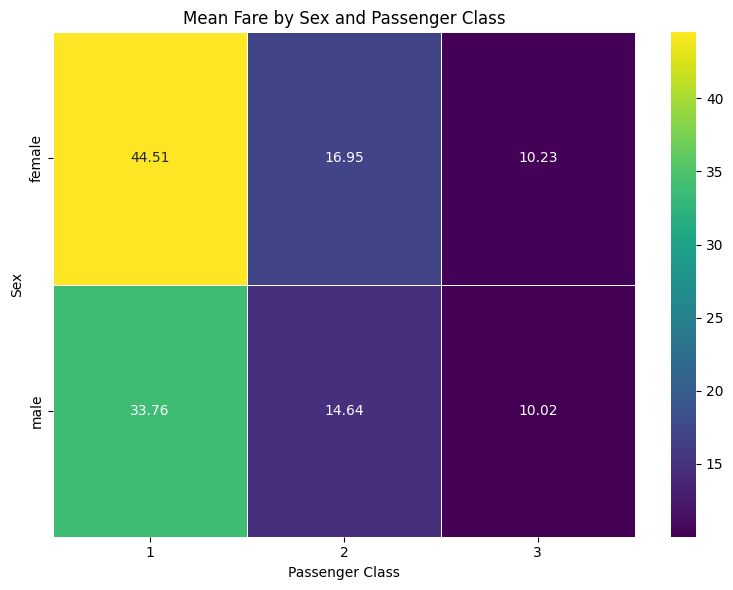

In [76]:
# 9-F  Pivot heatmap: mean Fare by Sex × Pclass

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for pivot_table

# Create the pivot table
pivot_data = inspector.df.pivot_table(values='Fare', index='Sex', columns='Pclass', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_data, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Mean Fare by Sex and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Sex')
plt.tight_layout()
plt.show()

# The original library call is commented out due to the AttributeError
# result = PLT.plot_heat_map(values='Fare',
#                             index='Sex',
#                             columns='Pclass',
#                             aggregade_method='mean',
#                             title='Mean Fare — Sex × Pclass',
#                             data=inspector.df)
# PLT.display_image(result)

In [78]:
import plotly.graph_objects as go
import pandas as pd

# Prepare the data for the Sankey diagram
# We need a source, a target, and a value for the flow

# Group by Embarked and Pclass and sum the Fare
sankey_data = inspector.df.groupby(['Embarked', 'Pclass'])['Fare'].sum().reset_index()

# Create unique labels for all nodes (Embarked cities and Pclass numbers)
all_nodes = pd.concat([sankey_data['Embarked'], sankey_data['Pclass'].astype(str)]).unique()
node_labels = list(all_nodes)

# Create mappings from node labels to integer indices
label_to_index = {label: i for i, label in enumerate(node_labels)}

# Prepare source, target, and value lists for plotly
source_indices = sankey_data['Embarked'].map(label_to_index).tolist()
target_indices = sankey_data['Pclass'].astype(str).map(label_to_index).tolist()
values = sankey_data['Fare'].tolist()

# Create the Sankey diagram
fig = go.Figure(data=[
    go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color='black', width=0.5),
            label=node_labels,
            # color="blue"
        ),
        link=dict(
            source=source_indices, # indices correspond to labels, so "Embarked" becomes 0, 1, 2, etc.
            target=target_indices,
            value=values,
        )
    )
])

fig.update_layout(title_text="Flow from Embarked Port to Passenger Class (weighted by Fare)", font_size=10)
fig.show()


In [80]:
import plotly.express as px
import pandas as pd

# Create the Sunburst chart using plotly.express
fig = px.sunburst(inspector.df,
                  path=['Sex', 'Pclass'],
                  values='Fare',
                  title='Fare Hierarchy: Sex → Passenger Class')

fig.show()
